In [44]:
# Data ko handle karne ke liye pandas
import pandas as pd

# Data ko training aur testing mein divide karne ke liye
from sklearn.model_selection import train_test_split

# Binary classification ke liye Logistic Regression
from sklearn.linear_model import LogisticRegression

# Model ki accuracy precision and recall check karne ke liye
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [45]:
df = pd.read_csv("train.csv")

In [46]:
df.shape     #isme maine check kiy KITNE ROWS HAI AND KITNE COLOUMNS HAI 

(891, 12)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [48]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
# Har column mein missing values check kar rahe hain
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [50]:
# ya maien analis kiya hai ki kitne log servive kiye hai unhe 1 se represet kiya and or kitne nahi kiye hai une 0 se reoresent kiya hai
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [51]:
# Sex ke according average survival rate dekh rahe hain
print(df.groupby("Sex")["Survived"].mean())


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [52]:
# Passenger class ke according average survival rate dekh rahe hain
print(df.groupby("Pclass")["Survived"].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


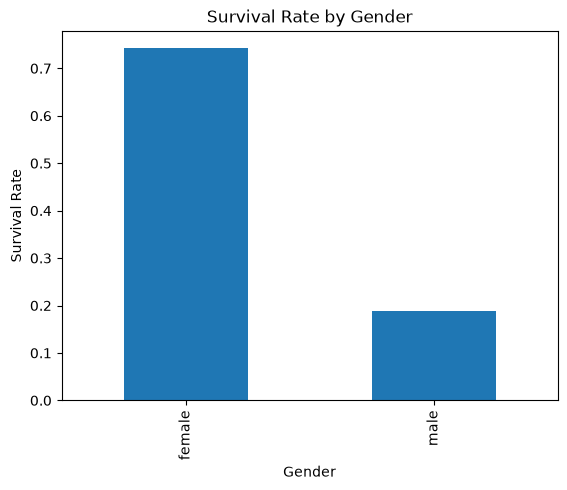

In [53]:
import matplotlib.pyplot as plt

df.groupby("Sex")["Survived"].mean().plot(kind="bar")

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.show()

In [54]:
# Age ki missing values ko median se fill kar rahe hain
df["Age"] = df["Age"].fillna(df["Age"].median()) 
   #Data ko ascending order mein arrange karne ke baad beech ki value median hoti hai. /#Q: Age mein median kyun use kiya?
# Kyunki Age numerical data hai aur median outliers se less affected hota hai.

In [55]:
2# Embarked ki missing values ko mode se fill kar rahe hain
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode())

In [56]:
3# Cabin mein bahut missing values hain, isliye remove kar rahe hain
df = df.drop("Cabin", axis=1)

In [57]:
4.# Unnecessary columns remove kar rahe hain
df = df.drop(["Name", "Ticket", "PassengerId"], axis=1)

In [58]:
5.# Categorical columns ko numerical form mein convert kar rahe hain
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

In [59]:
6# Preprocessing ke baad missing values check kar rahe hain
df.isnull().sum()

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

In [60]:
7# Preprocessing ke baad columns check kar rahe hain

df.columns


Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='str')

In [61]:
#5
X = df.drop("Survived", axis=1)   # X mein input features rakh rahe hain

y = df["Survived"]     # y mein target column rakh rahe hain


# Data ko 80% training aur 20% testing mein divide kar rahe hain
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Training aur testing data ka size check kar rahe hain
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (712, 8)
Testing: (179, 8)


Feature scaling se sabhi features ek similar scale par aa jate hain.
Isse model ko features ko compare karna easy hota hai.

In [62]:
# Feature Scaling: features ko same scale par lane ke liye
# Is dataset mein Age, Fare aur Pclass ki values ka scale different hai

from sklearn.preprocessing import StandardScaler

# Scaler bana rahe hain
scaler = StandardScaler()

# Training data ko scale kar rahe hain
X_train = scaler.fit_transform(X_train)

# Testing data ko same scale par scale kar rahe hain
X_test = scaler.transform(X_test)

In [63]:
# Logistic Regression model bana rahe hain
model = LogisticRegression(max_iter=1000)

# Training data par model train kar rahe hain
model.fit(X_train, y_train)

# Training data par prediction
y_train_pred = model.predict(X_train)

# Testing data par prediction
y_test_pred = model.predict(X_test)

# Training metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)

# Testing metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Training Precision:", train_precision)
print("Training Recall:", train_recall)

print("Testing Accuracy:", test_accuracy)
print("Testing Precision:", test_precision)
print("Testing Recall:", test_recall)

Training Accuracy: 0.800561797752809
Training Precision: 0.7560975609756098
Training Recall: 0.6940298507462687
Testing Accuracy: 0.8100558659217877
Testing Precision: 0.7857142857142857
Testing Recall: 0.7432432432432432


In [64]:
# Training Confusion Matrix
train_cm = confusion_matrix(y_train, y_train_pred)
TN_train, FP_train, FN_train, TP_train = train_cm.ravel()

print("Training Confusion Matrix:")
print(train_cm)
print("TN:", TN_train)
print("FP:", FP_train)
print("FN:", FN_train)
print("TP:", TP_train)


# Testing Confusion Matrix
test_cm = confusion_matrix(y_test, y_test_pred)
TN_test, FP_test, FN_test, TP_test = test_cm.ravel()

print("\nTesting Confusion Matrix:")
print(test_cm)
print("TN:", TN_test)
print("FP:", FP_test)
print("FN:", FN_test)
print("TP:", TP_test)

Training Confusion Matrix:
[[384  60]
 [ 82 186]]
TN: 384
FP: 60
FN: 82
TP: 186

Testing Confusion Matrix:
[[90 15]
 [19 55]]
TN: 90
FP: 15
FN: 19
TP: 55
